In [1]:
using LinearAlgebra
using Plots
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")


segment (generic function with 1 method)

In [2]:
controlx = [-1.5 -1.2 -0.7 -0.3 0. 0.3 0.7 1. 1.5]
controly = [0. 0.1 0.5 0.3 0. 0.6 0.45 0.1 0.] .+ 1.
control = vcat(controlx, controly)
control0 = control

2×9 Matrix{Float64}:
 -1.5  -1.2  -0.7  -0.3  0.0  0.3  0.7   1.0  1.5
  1.0   1.1   1.5   1.3  1.0  1.6  1.45  1.1  1.0

Fonction pour calculer efficement un vecteur de base (ensemble des points de contrôle)

Jacobienne du point d'impact sur le plan focal

In [3]:
#Fonction coût écart à un point
# Jeu de rayons parallèles en entrée
Nray = 1000
source0 = (Ray([-1. +  2*i / Nray, 0. ], pi / 2. ) for i in 0:Nray)
xstar = 0.

0.0

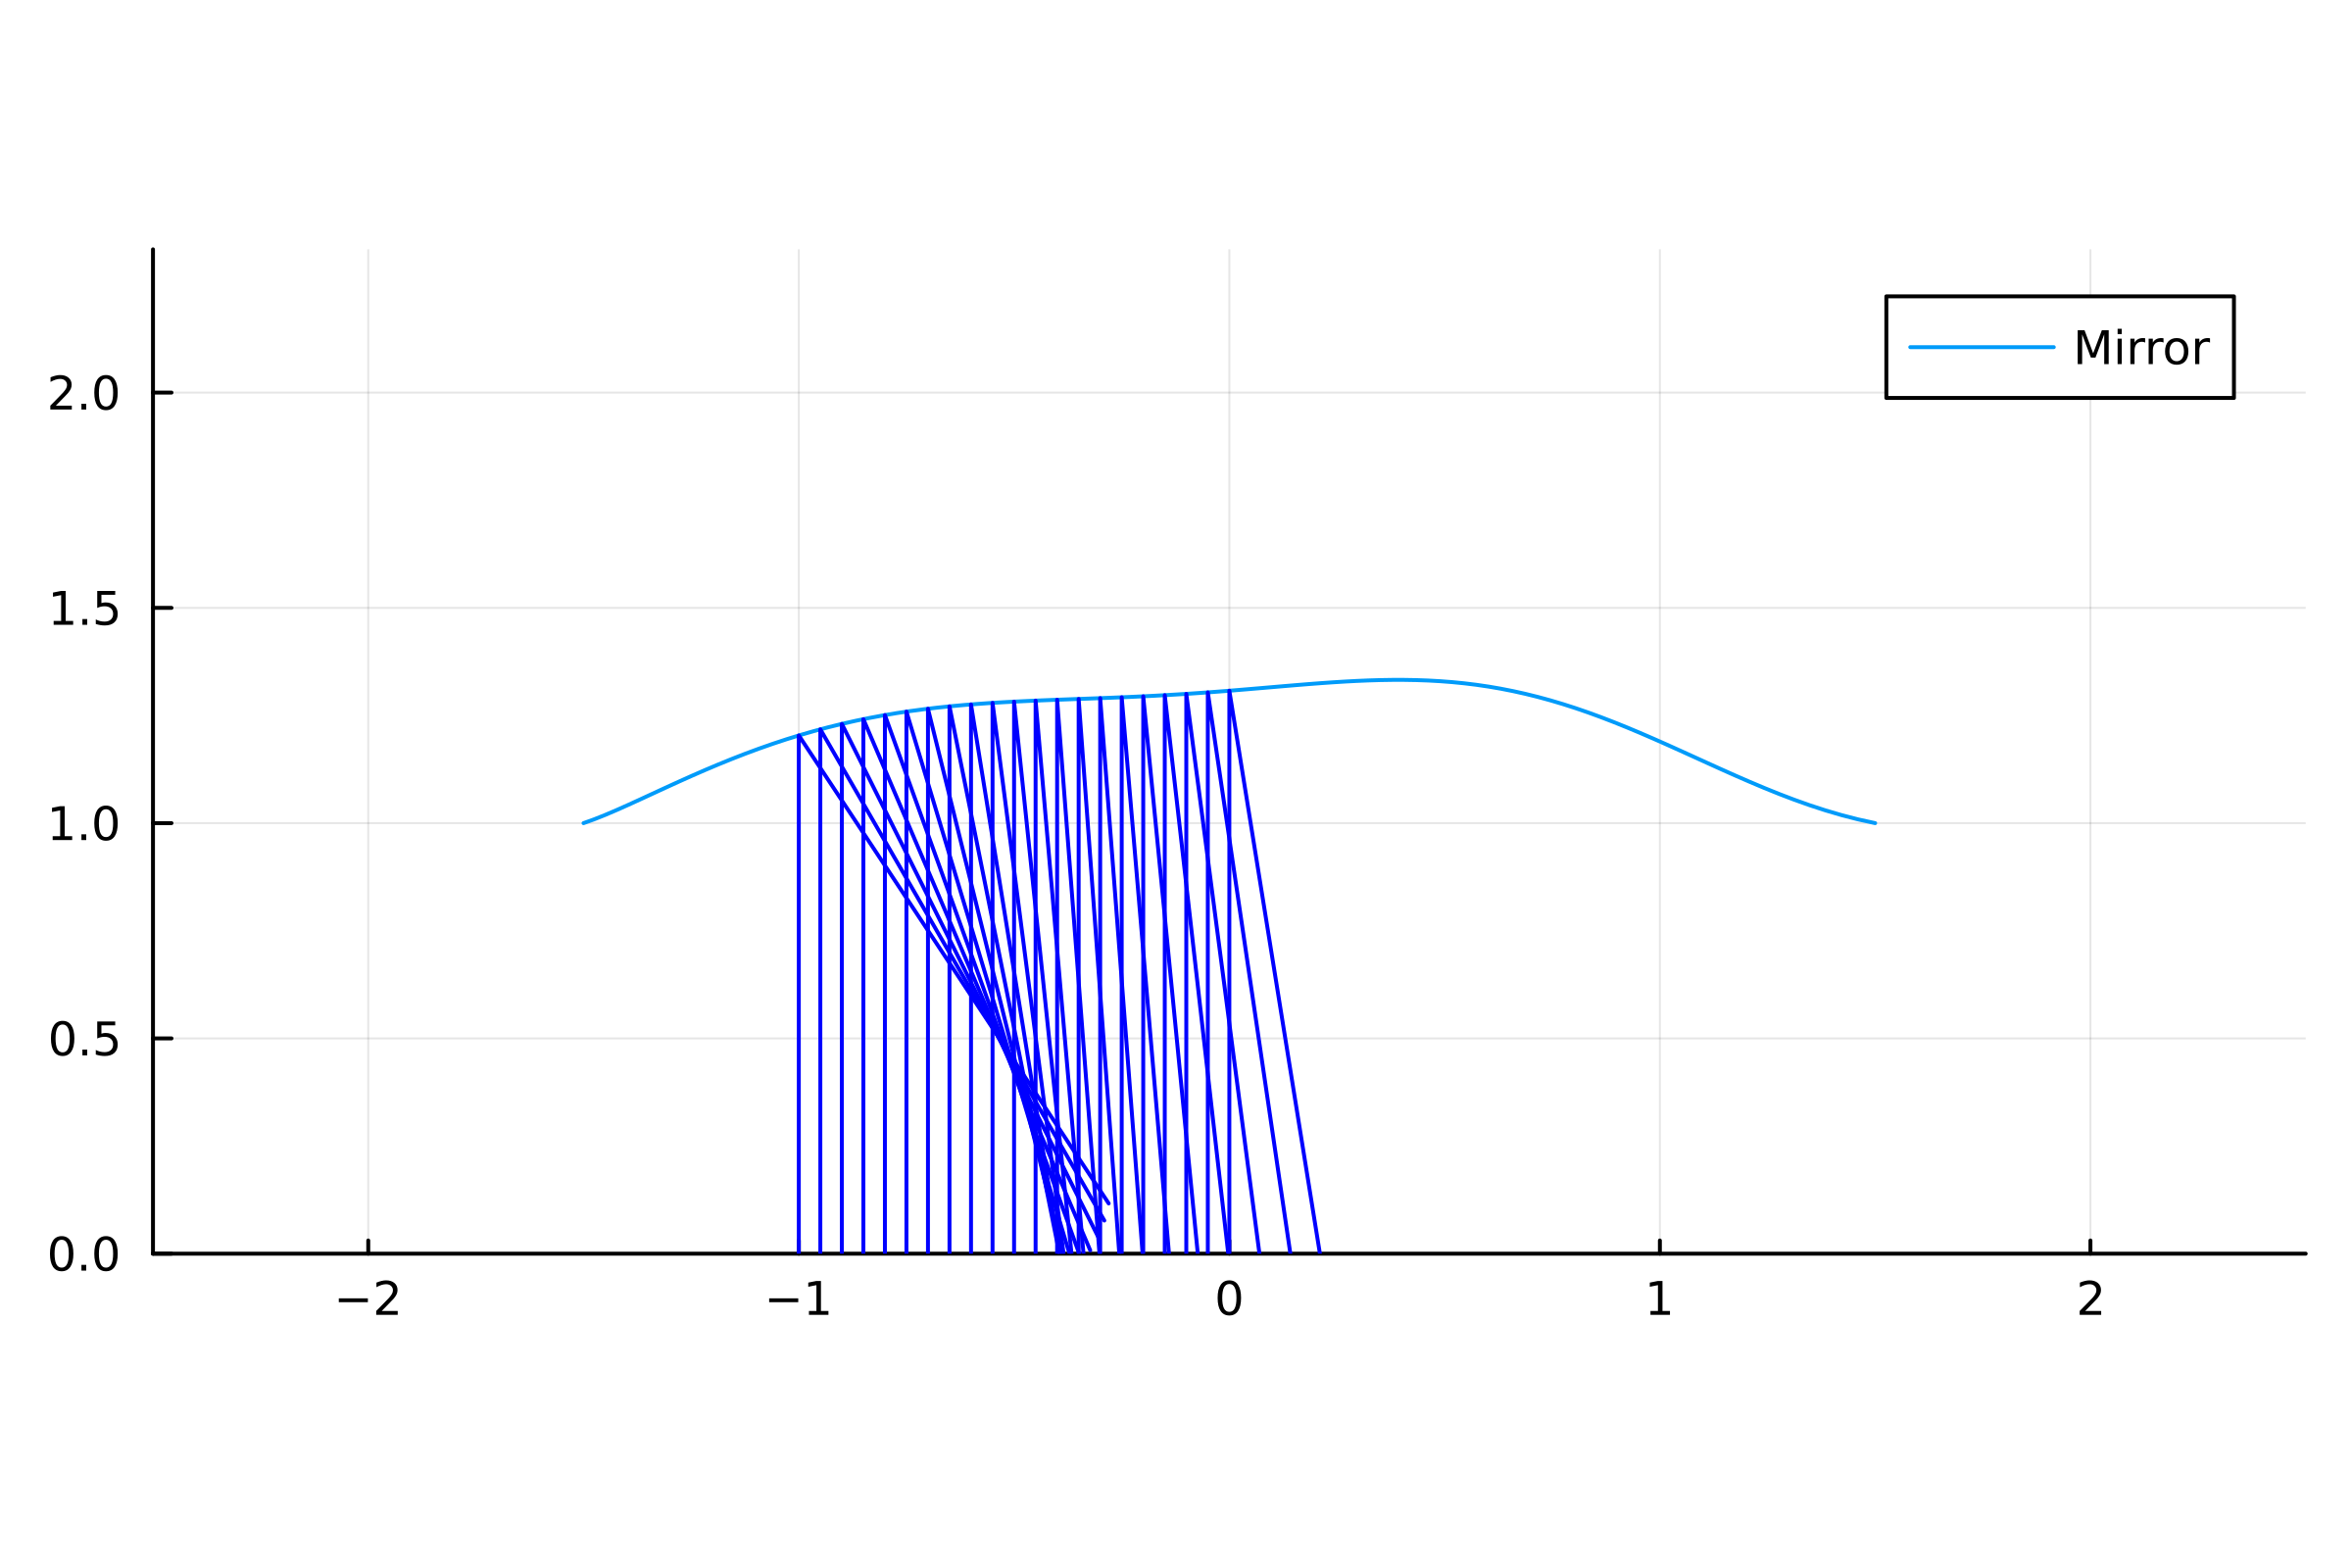

In [4]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror", dpi = 400)
source4plot = (Ray([-1. + i /20, 0. ], pi / 2. ) for i in 0:20)
for ray in source4plot
    plot!(ray)
end
savefig("init_rays_point.png")
display(plt)

In [5]:
source4plot = (Ray([-1. +  i / 20, 0. ], pi / 2. ) for i in 0:20)

Base.Generator{UnitRange{Int64}, var"#27#28"}(var"#27#28"(), 0:20)

In [6]:
function cross2d(vec1::Vector{Float64}, vec2::Vector{Float64})::Real
    return vec1[1]* vec2[2] - vec1[2]* vec2[1] 
end
cross2d([0.,1.], [1.,0.])

-1.0

In [7]:
#### fusionner jtilde
### fusionner projection focal (matrice par bloc ? utiliser strcture de julia)

function shapederimpactpoint(control::Matrix{Float64},i::Int64)::Vector{Float64}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    dr::Vector{Float64} = zeros(length(source0))
    ei = basiscontrol( n+1, (i <= n+1) * 1 + (i > n+1) * 2, (i <= n+1) * i + (i > n+1) * (i -(n+1))  )
    for (k,ray) in enumerate(source0)
        # on projette sur le miroir et on récupère le $t$ de param
        t = intersectionLine(control, ray) 
        dic = geometricquantities(control, t)
        theta = ray.angle
        #prendre un dangle et une normale sortante et renvoie l'angle correspondant au rayon réfléchi
        sdotn = dic["normal"][1] * cos(theta) + dic["normal"][2] * sin(theta)
        sdott = dic["utangent"][1] * cos(theta) + dic["utangent"][2] * sin(theta)
        thetaf = atan( sin(theta) - 2. * sdotn * dic["normal"][2], cos(theta) - 2. * sdotn * dic["normal"][1] )
        #on calcule les termes de la dérivée de formes
        sderterm = shapederivativeterms(control, t) #termes de la dérivée de formes
        rayr = Ray(dic["point"], thetaf)
        
        d = norm( projectionplanfocal(billiard(control,ray) ).pos - dic["point"] )
        xi= [cos(theta) ; sin(theta)]
        xif = [cos(thetaf);sin(thetaf)]
        a =  sdotn .* dic["utangent"] .+ sdott .* dic["normal"] 

        dX= dot(sderterm["thetan"], ei) .* xi ./ sdotn 
        dXI = 2. .*  ( dot(  sderterm["thetanprime"]  .+ dic["curvature"] .* (sdott /sdotn) .* sderterm["thetan"] , ei)  ) .* a 
        dr[k]= jacimpactpoint(d , dic["point"] , xif,  dX, dXI)[1] 
    end
    return dr
end


shapederimpactpoint (generic function with 1 method)

In [8]:
function variationimpactpointdiff(control::Matrix{Float64}, h::Float64,i::Int64)::Vector{Float64}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    dr::Vector{Float64} = zeros(length(source0))
    # 1 <= i <= 9 (i,1), sinon (i - 9, 2)
    ei = basiscontrol( n+1, (i <= n+1) * 1 + (i > n+1) * 2, (i <= n+1) * i + (i > n+1) * (i - (n+1))  )
    dcontroli = control + h.*  ei
    for (k,ray) in enumerate(source0)
        pointfocal = projectionplanfocal(billiard(control,ray) ).pos 
        pointfocali = projectionplanfocal(billiard(dcontroli ,ray) ).pos 
        dr[k] = (pointfocali[1] - pointfocal[1])
    end
    return dr
end

variationimpactpointdiff (generic function with 1 method)

In [9]:
p::Int64 = 10 #on fait bouger le point de contrôle p
h::Float64 = 1e-8
drformule = shapederimpactpoint(control,p) #matrice obtenue avec la formule
drdiff = variationimpactpointdiff(control, h,p) #matrice obtenue avec la différence finie
println( norm(drformule - drdiff)  )



17.715038098707172


$\Lambda$ is a reference shape, $1 \le i,j \le N_{control}$, $h$ is in abscissa,  $\sup_{1 \le k \le N_{ray}} |x_k(\Lambda + h e_{ij}) - x_k(\Lambda) - h dx_k(\Lambda)(e_{ij})|$

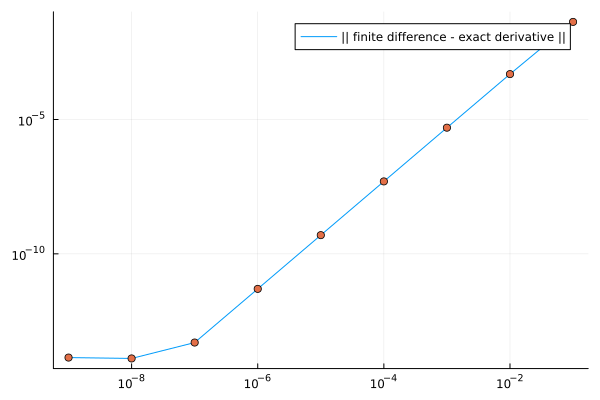

In [10]:
N = 9
residu = zeros(2,N)
for k in 1:N
    residu[1,k] = norm( variationimpactpointdiff(control, (10.)^(-k),p)  - (10.)^(-k) .* shapederimpactpoint(control,p)) 
end
absX =[ k for k in 1:N]
absX = (10.).^((-absX))
#plt = plot(absX,residu[1,:],label= "Différence finie")
#plot!(absX,residu[2,:],label= "Gradient")

plt = plot(absX,residu[1,:],label= "|| finite difference - exact derivative ||", xaxis =:log, yaxis =:log)
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
display(plt)

1


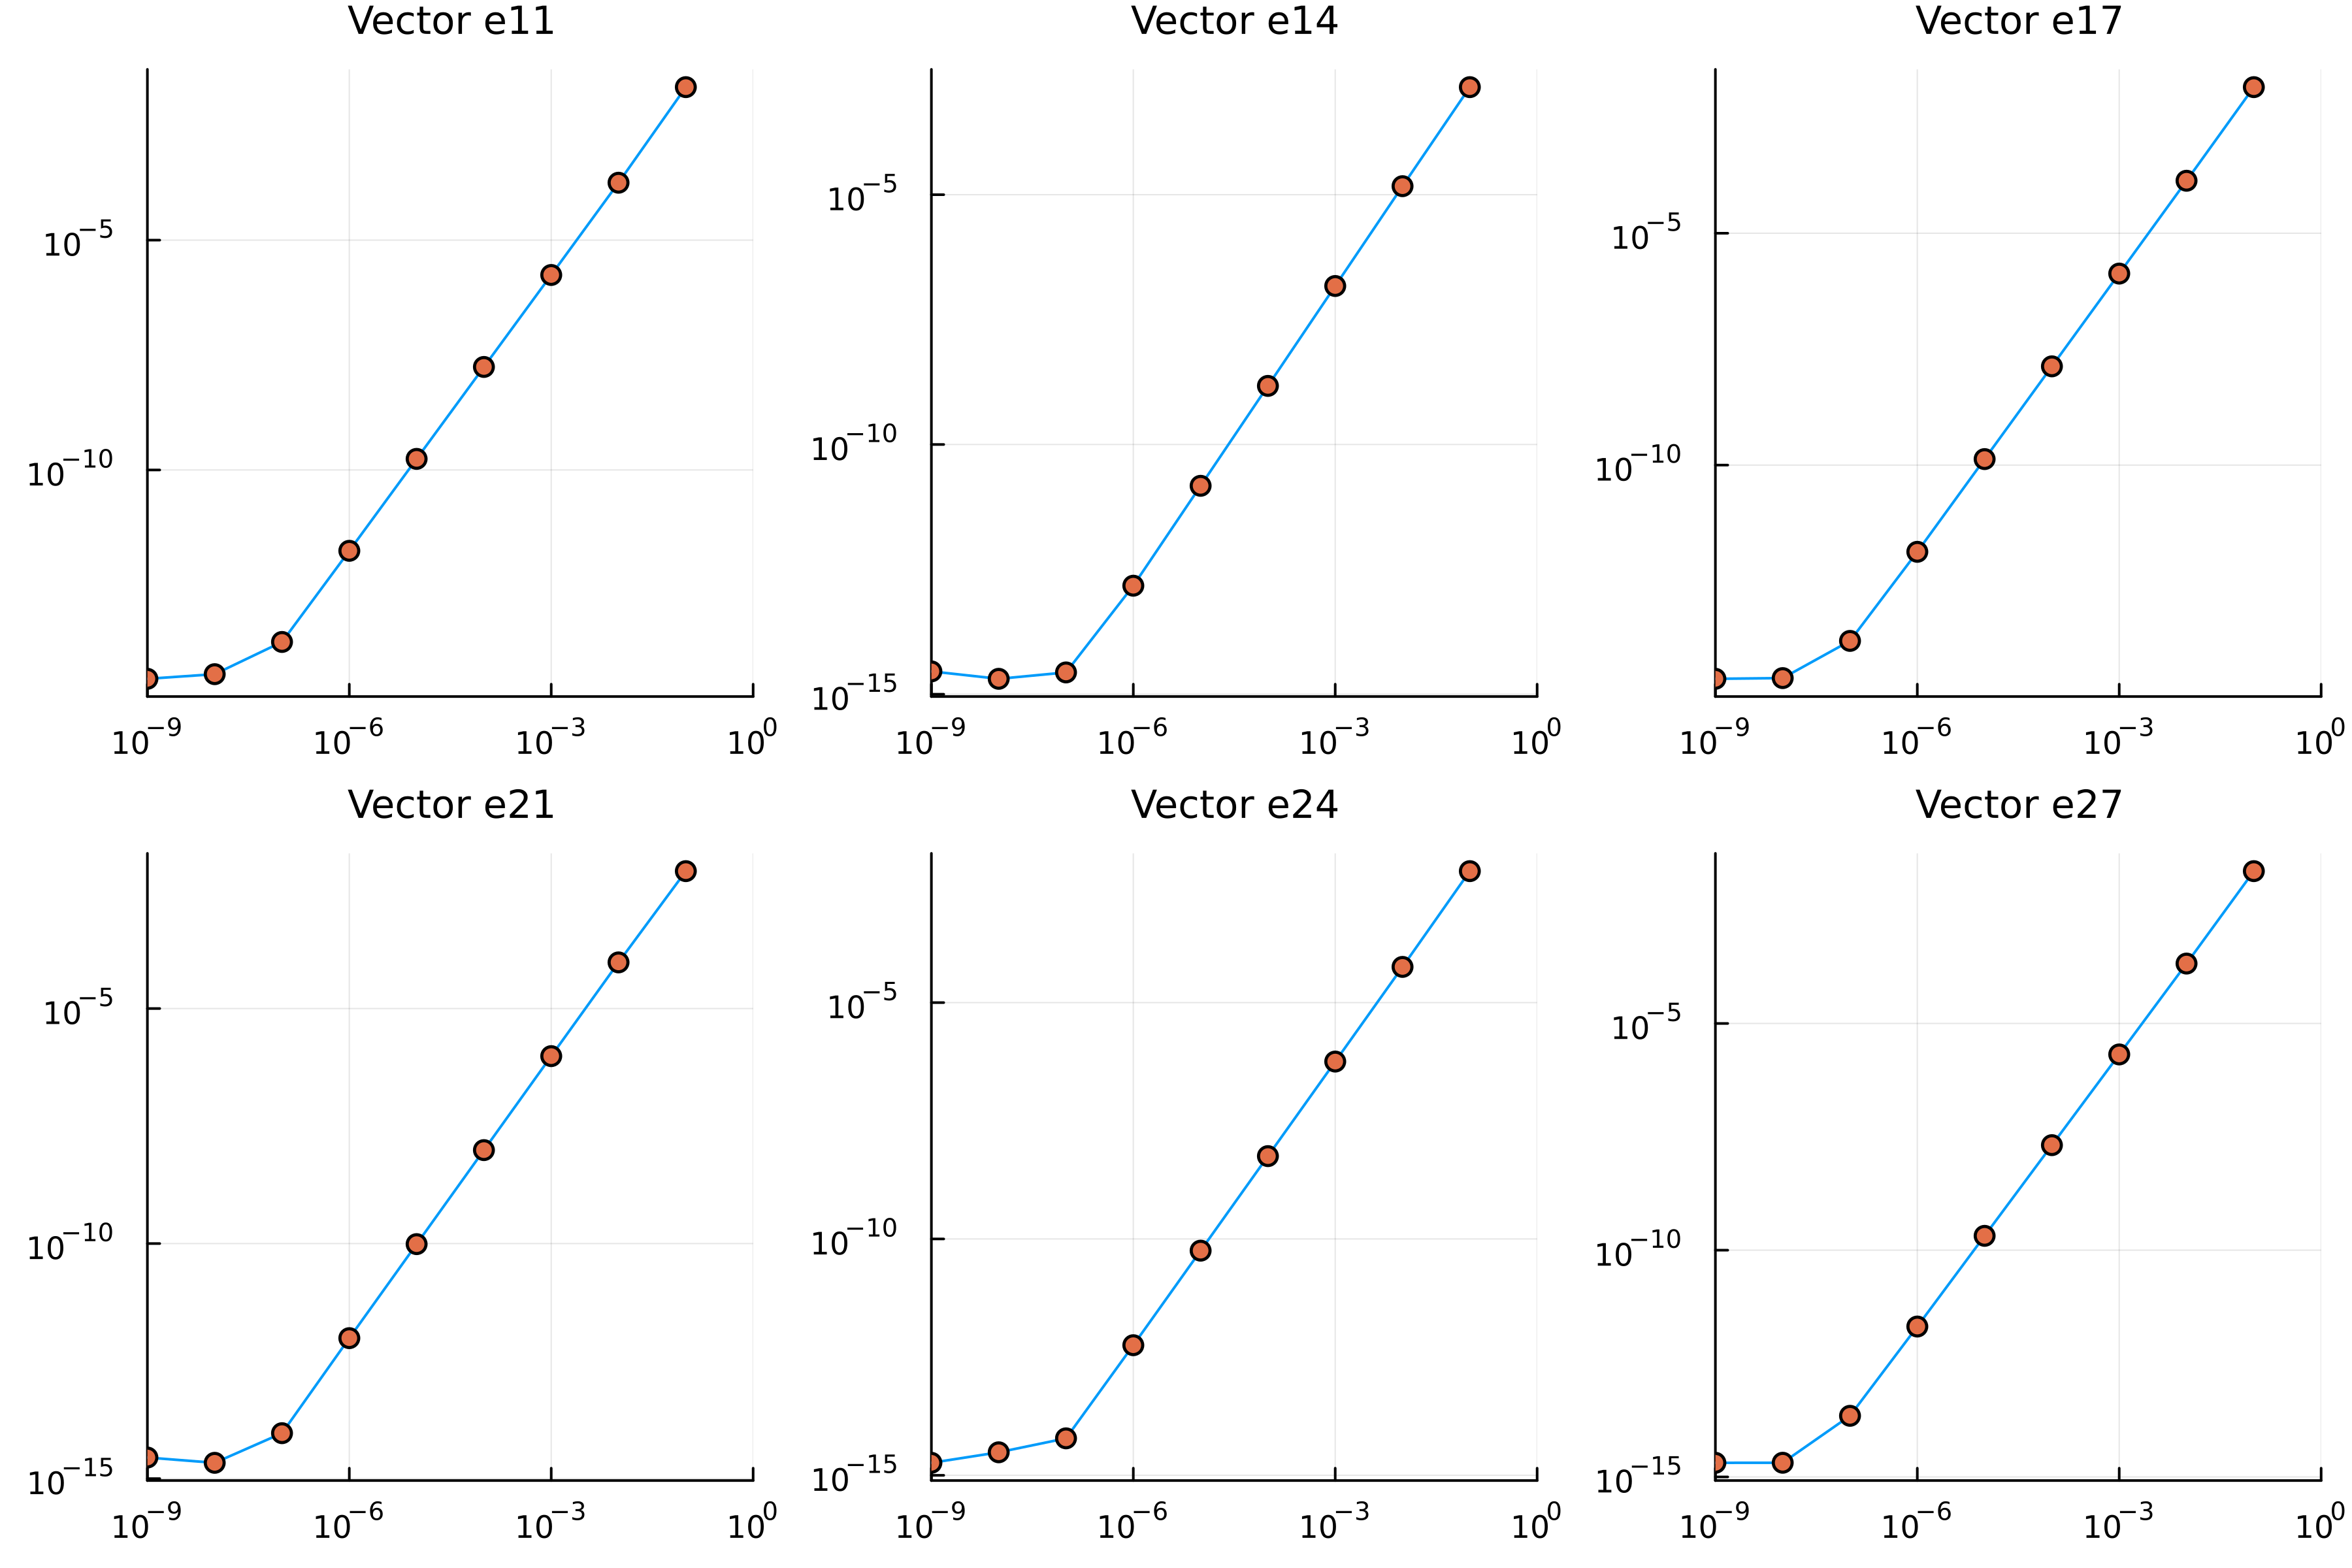

In [11]:
n::Int64 = size(control)[2]
dir = zeros(2,n)
N = 9
residu = zeros(2,N)
absX =[ k for k in 1:N]
absX = (10.).^((-absX))
#labelname = "||(f(x+h) - f(x) - f'(x)h)||"
labelname = false
#### 11 ###

p = 1  
posx = (p <= n) * 1 + (p > n) * 2
posy = (p <= n) * p + (p > n) * (p - n) 
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = norm(variationimpactpointdiff(control, (10.)^(-k),p) - (10.)^(-k) .* shapederimpactpoint(control,p), Inf) 
end

plt11 = plot(absX,residu[1,:],label=labelname, xaxis =:log, yaxis =:log, title = "Vector e11", titlefontsize = 10, dpi = 400, legend =:topright, xlim = (10^(-9),1))
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
dir[posx,posy] = 0.


#### 14 ###

p = 4
posx = (p <= n) * 1 + (p > n) * 2
posy = (p <= n) * p + (p > n) * (p - n) 
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] =  norm(variationimpactpointdiff(control, (10.)^(-k),p) - (10.)^(-k) .*  shapederimpactpoint(control,p), Inf) 
end

plt14 = plot(absX,residu[1,:],label= labelname, xaxis =:log, yaxis =:log, title = "Vector e14", titlefontsize = 10, dpi = 400, legend =:topright, xlim = (10^(-9),1))
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
dir[posx,posy] = 0.



#### 17 ###

p = 7  
posx = (p <= n) * 1 + (p > n) * 2
posy = (p <= n) * p + (p > n) * (p - n) 
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] = norm(variationimpactpointdiff(control, (10.)^(-k),p) - (10.)^(-k) .*  shapederimpactpoint(control,p), Inf)   
end

plt17 = plot(absX,residu[1,:],label= labelname, xaxis =:log, yaxis =:log, title = "Vector e17", titlefontsize = 10, dpi = 400, legend =:topright, xlim = (10^(-9),1))
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
dir[posx,posy] = 0.

#### 21 ###

p = 10  
posx = (p <= n) * 1 + (p > n) * 2
posy = (p <= n) * p + (p > n) * (p - n) 
println(posy)
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] =  norm(variationimpactpointdiff(control, (10.)^(-k),p)  - (10.)^(-k) .*  shapederimpactpoint(control,p), Inf)   
end

plt21 = plot(absX,residu[1,:],label= labelname, xaxis =:log, yaxis =:log, title = "Vector e21", titlefontsize = 10, dpi = 400, legend =:topright, xlim = (10^(-9),1))
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
dir[posx,posy] = 0.

#### 24 ###
p = 13  
posx = (p <= n) * 1 + (p > n) * 2
posy = (p <= n) * p + (p > n) * (p - n) 
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] =norm(variationimpactpointdiff(control, (10.)^(-k),p) - (10.)^(-k) .*  shapederimpactpoint(control,p), Inf) 
end

plt24 = plot(absX,residu[1,:],label= labelname, xaxis =:log, yaxis =:log, title = "Vector e24", titlefontsize = 10, dpi = 400, legend =:topright, xlim = (10^(-9),1))
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log)
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
dir[posx,posy] = 0.

#### 27 ###
p = 16
posx = (p <= n) * 1 + (p > n) * 2
posy = (p <= n) * p + (p > n) * (p - n) 
dir[posx,posy] = 1.
label = string(posx) * string(posy) 
for k in 1:N
    residu[1,k] =  norm( variationimpactpointdiff(control, (10.)^(-k),p)  - (10.)^(-k) .*  shapederimpactpoint(control,p) , Inf)   
end

plt27 = plot(absX,residu[1,:],label= labelname, xaxis =:log, yaxis =:log, title = "Vector e27", titlefontsize = 10, dpi = 400, legend =:topright, xlim = (10^(-9),1))
line = residu[1,1] .- [k for k in 1:N]
#plot!(absX, line, label = "line with expected slope", xaxis =:log, xlabel = "step")
scatter!(absX,residu[1,:], label = false, xaxis =:log, yaxis =:log)
dir[posx,posy] = 0.

plt = plot(plt11, plt14, plt17,  plt21, plt24, plt27,  layout = 6, size = (900,600), dpi = 400)
savefig("layout_verif_linear_pimpact_behave.png")
display(plt)